<a href="https://colab.research.google.com/github/Silvinharl/MVP_Machine_Learning/blob/main/MVP_Voos_ANAC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MVP - Predição de Atrasos em Voos Comerciais**






## *Parte I*

### **1. Definição do Problema**

O transporte aéreo é um setor altamente dependente de planejamento operacional e pontualidade. A ocorrência de atrasos impacta passageiros, companhias aéreas, aeroportos e toda a cadeia logística associada.

Neste trabalho será desenvolvido um modelo de Machine Learning capaz de prever se um voo apresentará atraso na chegada, utilizando informações disponíveis durante o planejamento operacional do voo.

O problema será tratado como uma tarefa de classificação supervisionada, onde a variável-alvo indicará se o voo chegou atrasado ou não.

O objetivo é avaliar se características como companhia aérea, aeroporto de origem, aeroporto de destino, capacidade da aeronave e horário previsto de partida possuem poder preditivo suficiente para identificar padrões associados aos atrasos.

Esse problema é adequado para Machine Learning porque existem exemplos históricos rotulados, permitindo que algoritmos aprendam padrões presentes nos dados e realizem previsões sobre novos voos.


### **2. Carregamento dos Dados**

Os dados utilizados neste trabalho foram obtidos a partir da base pública VRA (Voo Regular Ativo), disponibilizada pela Agência Nacional de Aviação Civil (ANAC), disponível em https://www.anac.gov.br/acesso-a-informacao/dados-abertos/areas-de-atuacao/voos-e-operacoes-aereas/voo-regular-ativo-vra/voo-regular-ativo-vra. A base original contém dados de vôos ocorridos a partir do ano 2000. Para este MVP, foi utilizado um corte inicial de janeiro a março de 2025.

Para garantir a reprodutibilidade do experimento, o dataset foi armazenado em um repositório público do GitHub e é carregado diretamente por URL.

Em relação ao dataset original (disponível no site da ANAC), foram preservadas apenas as colunas relevantes para o problema proposto. Os atributos não utilizados foram removidos do arquivo original antes do carregamento no repositório.

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/Silvinharl/MVP_Machine_Learning/main/dados/VRA_2025_01_C.csv"

df = pd.read_csv(url, sep=';')

print(df.shape)
df.head()

(250833, 6)


,Sigla Aerea,NumeroAssentos,Origem,Destino,Partida Prevista,Situacao Chegada
0,AAL,295,SBGL,KMIA,01/01/2025 23:55,Pontual
1,AAL,295,KMIA,SBGL,01/01/2025 01:10,Antecipado
2,AAL,318,SBGR,KMIA,01/01/2025 00:30,Antecipado
3,AAL,288,KMIA,SBGR,01/01/2025 23:50,Pontual
4,AAL,318,KMIA,SBGR,01/01/2025 20:50,Pontual


A base possui 250.833 registros e 6 atributos:

- Sigla Aerea
- NumeroAssentos
- Origem
- Destino
- Partida Prevista
- Situacao Chegada

#### 3.1 Descrição das Variáveis

| Variável | Descrição |
|-----------|-----------|
| Sigla Aerea | Companhia aérea responsável pelo voo |
| NumeroAssentos | Capacidade de assentos da aeronave |
| Origem | Aeroporto de origem do voo |
| Destino | Aeroporto de destino do voo |
| Partida Prevista | Data e horário previstos para a decolagem |
| Situacao Chegada | Classificação do horário de chegada do voo |

#### 3.2 Tipos das Variáveis

Observa-se que a variável NumeroAssentos possui natureza numérica, enquanto as demais variáveis são categóricas ou textuais.

A variável Partida Prevista será posteriormente convertida para o formato datetime, permitindo a extração de atributos temporais relevantes para a modelagem.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250833 entries, 0 to 250832
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Sigla Aerea       250833 non-null  object
 1   NumeroAssentos    250833 non-null  int64 
 2   Origem            250833 non-null  object
 3   Destino           250833 non-null  object
 4   Partida Prevista  244261 non-null  object
 5   Situacao Chegada  235988 non-null  object
dtypes: int64(1), object(5)
memory usage: 11.5+ MB


#### 3.3 Valores Ausentes
A análise inicial identificou valores ausentes nas colunas Partida Prevista e Situacao Chegada. Como essas variáveis são essenciais para o problema proposto, os registros incompletos serão tratados durante a etapa de preparação dos dados.

In [ ]:
df.isnull().sum()

,0
Sigla Aerea,0
NumeroAssentos,0
Origem,0
Destino,0
Partida Prevista,6572
Situacao Chegada,14845


A verificação de valores ausentes identificou 6.572 registros sem informação de Partida Prevista e 14.845 registros sem informação de Situacao Chegada.

Como ambas as variáveis são fundamentais para o desenvolvimento do modelo, esses registros serão removidos durante a etapa de preparação dos dados.

#### 3.4 Distribuição da Situação de Chegada

In [ ]:
df['Situacao Chegada'].value_counts()

,count
Situacao Chegada,
Antecipado,146411
Pontual,69159
Atraso 30-60,11429
Atraso 60-120,5611
Atraso 120-240,2283
Atraso > 240,1095


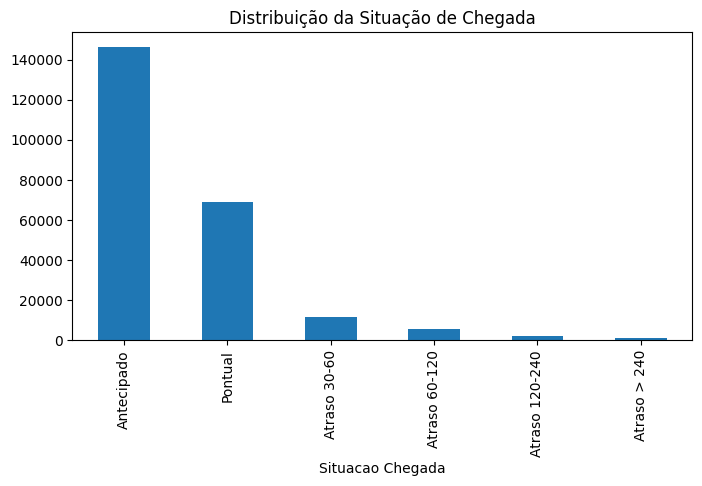

In [ ]:
import matplotlib.pyplot as plt

df['Situacao Chegada'].value_counts().plot(
    kind='bar',
    figsize=(8,4)
)

plt.title('Distribuição da Situação de Chegada')
plt.show()

A maioria dos voos foi classificada como Antecipado ou Pontual.

As categorias de atraso representam uma parcela menor da base de dados, indicando um cenário naturalmente desbalanceado.

Essa característica deverá ser considerada durante a avaliação dos modelos, utilizando métricas além da acurácia.

### **4. Preparação dos dados**

#### 4.1 Remoção dos registros incompletos

In [ ]:
df = df.dropna()

print(df.shape)

(235988, 6)


Nesta etapa foram realizados os tratamentos necessários para adequar os dados ao processo de modelagem.

Inicialmente, foram removidos os registros que apresentavam valores ausentes nas variáveis Partida Prevista ou Situacao Chegada.

Como ambas as variáveis são fundamentais para o problema proposto, optou-se pela remoção desses registros.

In [ ]:
df.isnull().sum()

,0
Sigla Aerea,0
NumeroAssentos,0
Origem,0
Destino,0
Partida Prevista,0
Situacao Chegada,0


#### 4.2 Variável-alvo
Para transformar o problema em uma tarefa de classificação binária, foi criada a variável atrasado.

A variável recebeu valor:

- 0 para voos classificados como Pontual ou Antecipado;
- 1 para voos classificados em qualquer categoria de atraso.

Essa transformação simplifica a modelagem e permite avaliar a capacidade dos algoritmos em identificar voos com potencial de atraso.

In [ ]:
df['atrasado'] = df['Situacao Chegada'].apply(
    lambda x: 1 if 'Atraso' in str(x) else 0
)

df['atrasado'].value_counts()

,count
atrasado,
0,215570
1,20418


#### 4.3 Engenharia de Atributos

A variável Partida Prevista foi convertida para o formato datetime.

A partir dela foram extraídos novos atributos temporais:

- hora_partida: hora prevista para a decolagem;
- minuto_partida: minuto previsto para a decolagem;
- dia_semana: dia da semana da operação, codificado de 0 (segunda-feira) a 6 (domingo);
- mes: mês da operação.

Essas variáveis foram criadas com o objetivo de capturar possíveis padrões temporais associados aos atrasos.

In [ ]:
df['Partida Prevista'] = pd.to_datetime(
    df['Partida Prevista'],
    format='%d/%m/%Y %H:%M',
    errors='coerce'
)
print(df['Partida Prevista'].dtype)
df['hora_partida'] = df['Partida Prevista'].dt.hour
df['minuto_partida'] = df['Partida Prevista'].dt.minute
df['dia_semana'] = df['Partida Prevista'].dt.dayofweek
df['mes'] = df['Partida Prevista'].dt.month

datetime64[ns]


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 235988 entries, 0 to 250832
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Sigla Aerea       235988 non-null  object        
 1   NumeroAssentos    235988 non-null  int64         
 2   Origem            235988 non-null  object        
 3   Destino           235988 non-null  object        
 4   Partida Prevista  235988 non-null  datetime64[ns]
 5   Situacao Chegada  235988 non-null  object        
 6   atrasado          235988 non-null  int64         
 7   hora_partida      235988 non-null  int32         
 8   minuto_partida    235988 non-null  int32         
 9   dia_semana        235988 non-null  int32         
 10  mes               235988 non-null  int32         
dtypes: datetime64[ns](1), int32(4), int64(2), object(4)
memory usage: 18.0+ MB


In [ ]:
df[['Partida Prevista',
    'hora_partida',
    'minuto_partida',
    'dia_semana',
    'mes']].head()

,Partida Prevista,hora_partida,minuto_partida,dia_semana,mes
0,2025-01-01 23:55:00,23,55,2,1
1,2025-01-01 01:10:00,1,10,2,1
2,2025-01-01 00:30:00,0,30,2,1
3,2025-01-01 23:50:00,23,50,2,1
4,2025-01-01 20:50:00,20,50,2,1


### **5. Análise dos Atributos**

Após a preparação dos dados, foi realizada uma análise exploratória das variáveis selecionadas para a modelagem.

O objetivo é identificar possíveis padrões entre os atributos disponíveis e a ocorrência de atrasos, auxiliando na compreensão do problema e na interpretação futura dos modelos.

#### 5.1 Análise 1 — Companhias aéreas

In [ ]:
companhias = (
    df.groupby('Sigla Aerea')['atrasado']
      .mean()
      .sort_values(ascending=False)
)

companhias.head(15)

,atrasado
Sigla Aerea,
CKS,1.000000
HFY,0.800000
CJT,0.750000
GXA,0.714286
GTI,0.668874
LYC,0.666667
LCO,0.653913
NCR,0.628571
LAE,0.593548


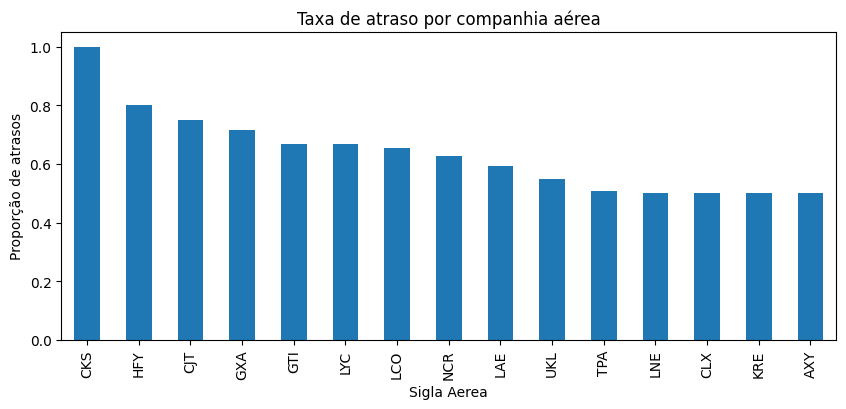

In [ ]:
import matplotlib.pyplot as plt

companhias.head(15).plot(
    kind='bar',
    figsize=(10,4)
)

plt.title('Taxa de atraso por companhia aérea')
plt.ylabel('Proporção de atrasos')
plt.show()

#### 5.2 Análise 2 — Hora da partida

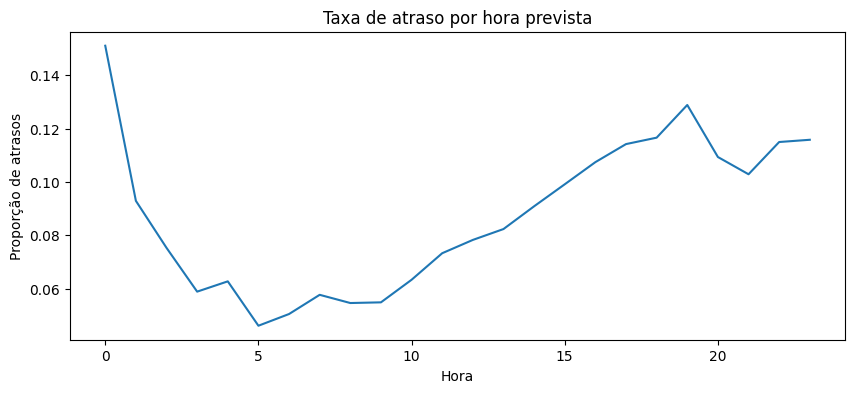

In [ ]:
hora = (
    df.groupby('hora_partida')['atrasado']
      .mean()
)

hora.plot(
    figsize=(10,4)
)

plt.title('Taxa de atraso por hora prevista')
plt.ylabel('Proporção de atrasos')
plt.xlabel('Hora')
plt.show()

#### 5.3 Análise 3 — Aeroportos de origem

In [ ]:
origem = (
    df.groupby('Origem')['atrasado']
      .mean()
      .sort_values(ascending=False)
)

origem.head(15)

,atrasado
Origem,
KSEA,1.000000
SANT,1.000000
SDSC,1.000000
TJSJ,1.000000
TLPL,1.000000
SKBQ,1.000000
VTBS,1.000000
KPHX,0.875000
SLCB,0.758621


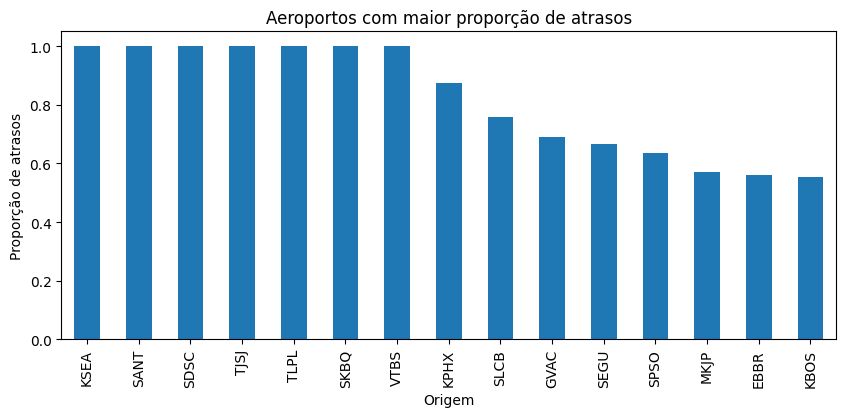

In [ ]:
origem.head(15).plot(
    kind='bar',
    figsize=(10,4)
)

plt.title('Aeroportos com maior proporção de atrasos')
plt.ylabel('Proporção de atrasos')
plt.show()

#### 5.4 Análise 4 — Aeroportos de destino

In [ ]:
destino = (
    df.groupby('Destino')['atrasado']
      .mean()
      .sort_values(ascending=False)
)

destino.head(15)

,atrasado
Destino,
KTPA,1.000000
MNMG,1.000000
KSEA,1.000000
SKPE,1.000000
ZBTJ,1.000000
TJSJ,1.000000
MKJP,0.857143
SANT,0.800000
GVAC,0.709091


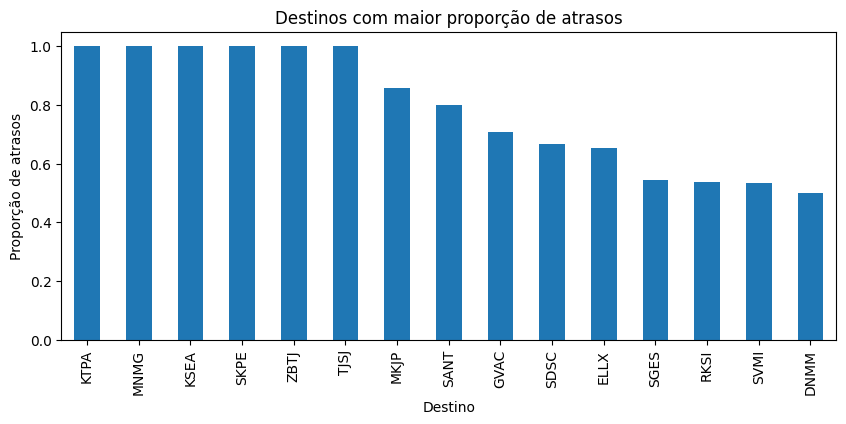

In [ ]:
destino.head(15).plot(
    kind='bar',
    figsize=(10,4)
)

plt.title('Destinos com maior proporção de atrasos')
plt.ylabel('Proporção de atrasos')
plt.show()

#### 5.5 Refinamento da Análise

A análise inicial identificou companhias aéreas e aeroportos com taxas extremamente elevadas de atraso, chegando a 100% em alguns casos.

Entretanto, observou-se que parte desses resultados estava associada a grupos com quantidade muito reduzida de observações.

Nessas situações, uma única ocorrência de atraso pode produzir taxas artificialmente elevadas, comprometendo a interpretação dos resultados.

Por esse motivo, foi realizada uma análise complementar considerando também a quantidade de voos observados para cada companhia aérea e aeroporto.

In [ ]:
companhias_stats = (
    df.groupby('Sigla Aerea')
      .agg(
          taxa_atraso=('atrasado','mean'),
          qtd_voos=('atrasado','count')
      )
)

companhias_stats.sort_values(
    'taxa_atraso',
    ascending=False
).head(15)

,taxa_atraso,qtd_voos
Sigla Aerea,,
CKS,1.000000,2
HFY,0.800000,10
CJT,0.750000,8
GXA,0.714286,14
GTI,0.668874,302
LYC,0.666667,3
LCO,0.653913,575
NCR,0.628571,35
LAE,0.593548,155


In [ ]:
origem_stats = (
    df.groupby('Origem')
      .agg(
          taxa_atraso=('atrasado','mean'),
          qtd_voos=('atrasado','count')
      )
)

origem_stats.sort_values(
    'taxa_atraso',
    ascending=False
).head(15)

,taxa_atraso,qtd_voos
Origem,,
KSEA,1.000000,1
SANT,1.000000,3
SDSC,1.000000,2
TJSJ,1.000000,2
TLPL,1.000000,1
SKBQ,1.000000,1
VTBS,1.000000,3
KPHX,0.875000,8
SLCB,0.758621,58


In [ ]:
destino_stats = (
    df.groupby('Destino')
      .agg(
          taxa_atraso=('atrasado','mean'),
          qtd_voos=('atrasado','count')
      )
)

destino_stats.sort_values(
    'taxa_atraso',
    ascending=False
).head(15)

,taxa_atraso,qtd_voos
Destino,,
KTPA,1.000000,1
MNMG,1.000000,1
KSEA,1.000000,1
SKPE,1.000000,1
ZBTJ,1.000000,1
TJSJ,1.000000,2
MKJP,0.857143,7
SANT,0.800000,5
GVAC,0.709091,110


#### 5.6 Análise com Controle de Frequência

A análise complementar confirmou que parte dos resultados observados inicialmente estava associada a grupos com número reduzido de observações.

Companhias aéreas e aeroportos que apresentavam taxas de atraso extremamente elevadas frequentemente possuíam apenas alguns poucos voos registrados na base de dados.

Para reduzir o impacto de flutuações ocasionais e aumentar a confiabilidade das interpretações, foi aplicado um critério mínimo de frequência, considerando apenas grupos com pelo menos 100 voos registrados.

Essa abordagem permitiu identificar padrões mais consistentes e representativos do comportamento operacional observado no período analisado.

In [ ]:
companhias_filtradas = companhias_stats[
    companhias_stats['qtd_voos'] >= 100
]

companhias_filtradas.sort_values(
    'taxa_atraso',
    ascending=False
).head(15)

,taxa_atraso,qtd_voos
Sigla Aerea,,
GTI,0.668874,302
LCO,0.653913,575
LAE,0.593548,155
TPA,0.508850,226
CLX,0.500000,206
LTG,0.488889,585
KAL,0.428571,182
BOV,0.386905,336
FBZ,0.361793,937


In [ ]:
origem_filtrada = origem_stats[
    origem_stats['qtd_voos'] >= 100
]

origem_filtrada.sort_values(
    'taxa_atraso',
    ascending=False
).head(15)

,taxa_atraso,qtd_voos
Origem,,
GVAC,0.690265,113
EBBR,0.559633,109
SEQM,0.391566,166
KMIA,0.345934,1402
SBUY,0.280576,139
KDFW,0.269737,152
SLVR,0.234043,188
KIAH,0.220994,181
LPPT,0.209354,1347


In [ ]:
destino_filtrado = destino_stats[
    destino_stats['qtd_voos'] >= 100
]

destino_filtrado.sort_values(
    'taxa_atraso',
    ascending=False
).head(15)

,taxa_atraso,qtd_voos
Destino,,
GVAC,0.709091,110
KDFW,0.456954,151
SEQM,0.394636,261
LTFM,0.290123,162
KATL,0.252830,265
EDDF,0.247093,344
KMIA,0.237465,1057
SBUY,0.230769,143
SLVR,0.225806,248


Durante a análise exploratória foram identificadas categorias com baixa frequência de ocorrência, incluindo algumas companhias aéreas e aeroportos com poucos registros disponíveis.

Reconhece-se que categorias muito raras podem introduzir ruído e favorecer padrões específicos de treinamento, representando uma potencial limitação do modelo, entretanto, essas categorias foram mantidas na modelagem por representarem observações válidas da base de dados.

### **6. Preparação para Modelagem**

Após a etapa de análise exploratória e engenharia de atributos, os dados foram preparados para utilização nos algoritmos de Machine Learning.

A variável-alvo utilizada foi `atrasado`, criada durante a etapa de preparação dos dados.

As variáveis categóricas foram transformadas para formato numérico por meio de codificação apropriada, permitindo sua utilização pelos algoritmos de classificação.

Por fim, os dados foram divididos em conjuntos de treinamento e teste para avaliação do desempenho dos modelos.

#### 6.1 Definição de x e y

In [ ]:
X = df[
    [
        'Sigla Aerea',
        'NumeroAssentos',
        'Origem',
        'Destino',
        'hora_partida',
        'minuto_partida',
        'dia_semana',
        'mes'
    ]
]

y = df['atrasado']
print(X.shape)
print(y.shape)

(235988, 8)
(235988,)


In [ ]:
X.dtypes

,0
Sigla Aerea,object
NumeroAssentos,int64
Origem,object
Destino,object
hora_partida,int32
minuto_partida,int32
dia_semana,int32
mes,int32


#### 6.2 One-Hot Encoding
As variáveis Sigla Aerea, Origem e Destino possuem natureza categórica e não podem ser utilizadas diretamente por alguns algoritmos de Machine Learning.

Para resolver esse problema foi utilizada a técnica One-Hot Encoding, que transforma cada categoria em uma variável binária.

Essa abordagem permite representar informações categóricas de forma adequada sem introduzir relações artificiais entre categorias.

In [ ]:
X = pd.get_dummies(
    X,
    columns=[
        'Sigla Aerea',
        'Origem',
        'Destino'
    ],
    drop_first=True
)

In [ ]:
print(X.shape)

(235988, 587)


#### 6.3 Divisão de dados
Os dados foram divididos em conjuntos de treinamento e teste.

O conjunto de treinamento foi utilizado para o ajuste dos modelos, enquanto o conjunto de teste foi reservado para avaliação final do desempenho.

Foi adotada uma divisão de 80% para treinamento e 20% para teste.

Além disso, utilizou-se a estratégia de estratificação da variável-alvo, preservando a proporção entre voos atrasados e não atrasados em ambos os conjuntos.

Essa abordagem preserva a proporção entre voos atrasados e não atrasados nos conjuntos de treinamento e teste, garantindo que ambos representem adequadamente a distribuição observada na base original.

A estratificação é particularmente importante neste trabalho devido ao desbalanceamento identificado entre as classes, reduzindo o risco de avaliações enviesadas dos modelos.

Como a base possui aproximadamente 236 mil registros, a divisão holdout estratificada 80/20 já fornece conjuntos de treino e teste suficientemente grandes para produzir estimativas estáveis de desempenho. A validação cruzada poderia ser utilizada em trabalhos futuros para uma avaliação ainda mais robusta.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Foi utilizado random_state=42 para garantir a reprodutibilidade dos experimentos.

Dessa forma, as etapas de divisão dos dados e treinamento dos modelos produzem resultados consistentes em diferentes execuções.

In [ ]:
print(X_train.shape)
print(X_test.shape)

(188790, 587)
(47198, 587)


### **7. Modelo baseline**
Antes do treinamento dos modelos principais, foi construído um modelo baseline utilizando o algoritmo DummyClassifier.

O objetivo do baseline é fornecer uma referência mínima de desempenho.

Dessa forma, será possível verificar se os modelos de Machine Learning realmente conseguem aprender padrões presentes nos dados ou apenas reproduzir comportamentos triviais da base.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

baseline = DummyClassifier(
    strategy='most_frequent'
)

baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

In [ ]:
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_baseline)
)

Accuracy: 0.9134709097843129


O modelo baseline apresentou acurácia de aproximadamente 91%.

Entretanto, uma análise mais detalhada da matriz de confusão e das métricas de classificação revelou que o modelo não foi capaz de identificar nenhum voo atrasado.

Esse comportamento ocorre porque o DummyClassifier, configurado com a estratégia "most_frequent", prevê sempre a classe majoritária da base de dados, correspondente aos voos não atrasados.

O resultado evidencia que a acurácia isoladamente não é suficiente para avaliar modelos em problemas com classes desbalanceadas.

Dessa forma, as métricas Precision, Recall e F1-Score serão utilizadas nas próximas etapas para complementar a avaliação dos modelos.

In [ ]:
confusion_matrix(
    y_test,
    y_pred_baseline
)

array([[43114,     0],
       [ 4084,     0]])

In [ ]:
print(
    classification_report(
        y_test,
        y_pred_baseline
    )
)

              precision    recall  f1-score   support

           0       0.91      1.00      0.95     43114
           1       0.00      0.00      0.00      4084

    accuracy                           0.91     47198
   macro avg       0.46      0.50      0.48     47198
weighted avg       0.83      0.91      0.87     47198



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


A análise das métricas revelou que o modelo baseline não realizou nenhuma previsão da classe correspondente aos voos atrasados.

Como consequência, as métricas Precision, Recall e F1-Score para essa classe foram iguais a zero.

Esse resultado reforça a limitação de modelos que consideram apenas a classe majoritária em bases desbalanceadas.

### **8. Logistic Regression**

Logistic Regression foi utilizada como primeiro modelo de classificação supervisionada.

Esse algoritmo é amplamente empregado em problemas de classificação binária devido à sua simplicidade, interpretabilidade e eficiência computacional.

Como o algoritmo é sensível à escala das variáveis numéricas, foi aplicada uma etapa de padronização utilizando o StandardScaler antes do treinamento.

In [ ]:
X_train_lr = X_train.copy()
X_test_lr = X_test.copy()

In [ ]:
colunas_numericas = [
    'NumeroAssentos',
    'hora_partida',
    'minuto_partida',
    'dia_semana',
    'mes'
]

colunas_numericas

['NumeroAssentos', 'hora_partida', 'minuto_partida', 'dia_semana', 'mes']

#### 8.1 Padronização das Variáveis

As variáveis numéricas foram padronizadas utilizando o StandardScaler.

O ajuste do escalonador foi realizado exclusivamente sobre o conjunto de treinamento, sendo posteriormente aplicado ao conjunto de teste.

Essa abordagem evita vazamento de informação entre os conjuntos e garante uma avaliação mais realista do modelo.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_lr[colunas_numericas] = scaler.fit_transform(
    X_train_lr[colunas_numericas]
)

X_test_lr[colunas_numericas] = scaler.transform(
    X_test_lr[colunas_numericas]
)

In [ ]:
X_train_lr[colunas_numericas].describe()

,NumeroAssentos,hora_partida,minuto_partida,dia_semana,mes
count,1.887900e+05,1.887900e+05,1.887900e+05,1.887900e+05,1.887900e+05
mean,1.108306e-16,-6.925148e-18,-9.766716e-17,1.966516e-17,-3.522793e-17
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00
min,-2.608759e+00,-2.167785e+00,-1.503261e+00,-1.500659e+00,-1.176933e+00
25%,-4.859982e-01,-8.168508e-01,-9.362382e-01,-9.965132e-01,-1.176933e+00
50%,2.007773e-01,2.748346e-02,-8.570397e-02,1.177917e-02,2.951742e-02
75%,2.944285e-01,8.718177e-01,7.648302e-01,1.020072e+00,1.235968e+00
max,5.429636e+00,1.716152e+00,1.842174e+00,1.524218e+00,2.442418e+00


#### 8.2 Treinamento do modelo

In [ ]:
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(
    random_state=42,
    max_iter=500,
    solver='liblinear',
    class_weight='balanced'
)

modelo_lr.fit(X_train_lr, y_train)

LogisticRegression(class_weight='balanced', max_iter=500, random_state=42,
                   solver='liblinear')

#### 8.3 Teste do modelo

In [ ]:
y_pred_lr = modelo_lr.predict(
    X_test_lr
)

#### 8.4 Acurácia

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Accuracy: 0.6758760964447647


#### 8.5 Matriz de Confusão

In [ ]:
confusion_matrix(y_test, y_pred_lr)

array([[29453, 13661],
       [ 1637,  2447]])

Número de iterações usadas até a convergência:

In [ ]:
modelo_lr.n_iter_

array([11], dtype=int32)

A Regressão Logística apresentou acurácia inferior ao modelo baseline.

Entretanto, diferentemente do baseline, o modelo foi capaz de identificar uma parcela significativa dos voos atrasados.

Esse resultado demonstra que a redução da acurácia não necessariamente representa pior desempenho, uma vez que o objetivo principal do problema é identificar atrasos e não apenas maximizar o número total de acertos.

A utilização do parâmetro class_weight='balanced' contribuiu para reduzir o impacto do desbalanceamento das classes durante o treinamento.

In [ ]:
print(classification_report(
    y_test,
    y_pred_lr)
)

              precision    recall  f1-score   support

           0       0.95      0.68      0.79     43114
           1       0.15      0.60      0.24      4084

    accuracy                           0.68     47198
   macro avg       0.55      0.64      0.52     47198
weighted avg       0.88      0.68      0.75     47198



#### 8.6 Interpretação dos resultados

##### Classe 0 - Não atrasados

Temos 47.198 registros na base de teste. Durante o teste, o modelo classificou 31.090 (29.453 + 1.637)registros como "Não atrasado". Dessas, ele acertou em 29.453 vezes, obtendo uma precisão de 95%.
No entanto, na base de teste havia 43.114 vôos (29.453 + 13.661) que realmente não atrasaram, dos quais o modelo identificou apenas 29.453, resultando em um recall de 68%.

#### #Classe 1 - Atrasados
Dos 47.198 registros, o modelo classificou 16.108 registros como "Atrasado" durante os testes, acertando em 2.447 ocorrências.
No entanto, na base de teste havia 4.084 vôos que de fato atrasaram, dos quais o modelo identificou 2.447, resultando em um recall de 60%.

Em resumo, a Regressão Logística apresentou comportamentos distintos para cada classe.

Quando o modelo prevê que um voo não irá atrasar, demonstra elevada confiabilidade, acertando aproximadamente 95% dessas previsões.

Por outro lado, quando prevê que um voo irá atrasar, a taxa de acerto é de apenas 15%, indicando a ocorrência de um número elevado de falsos positivos.

Apesar disso, o modelo foi capaz de identificar cerca de 60% dos atrasos reais, desempenho significativamente superior ao modelo baseline, que não identificava nenhum caso de atraso.

Esses resultados demonstram que, para este problema, métricas como Precision e Recall fornecem uma visão mais adequada do desempenho do modelo do que a acurácia isoladamente.

### **9. Random Forest**
O modelo baseline atingiu acurácia de 91%, mas com um recall de "Atraso" de 0%, indicando que o modelo conseguiu prever os vôos não atrasados, mas não encontrou nenhum dos vôos que atrasariam.

Já a Regressão Logística atingiu uma acurárcia de 68%, com um recall de "Atraso" de 60%, mas com uma precisão de 15%.Ou seja, ela até consegue encontrar os atrasos, mas gera muitos falsos-positivos no processo.

A Random Forest foi utilizada como modelo de classificação baseado em árvores de decisão.

Esse algoritmo combina diversas árvores treinadas sobre subconjuntos dos dados, reduzindo o risco de overfitting e permitindo capturar relações mais complexas entre as variáveis.

O Objetivo é manter o recall em níveis razoáveis e melhorar a precisão.

Diferentemente da Regressão Logística, a Random Forest não requer padronização dos atributos numéricos.


#### 9.1 Treinamento do modelo

In [ ]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

modelo_rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

Foi utilizada uma floresta composta por 100 árvores de decisão.

Além disso, foi mantida a estratégia de balanceamento das classes para reduzir o impacto do desbalanceamento observado na variável-alvo.

#### 9.2 Teste do modelo

In [ ]:
y_pred_rf = modelo_rf.predict(
    X_test
)

#### 9.3 Acurácia

In [ ]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred_rf
    )
)

Accuracy: 0.8150980973770074


#### 9.4 Matriz de confusão

In [ ]:
confusion_matrix(
    y_test,
    y_pred_rf
)

array([[37204,  5910],
       [ 2817,  1267]])

A Random Forest apresentou acurácia superior à Regressão Logística, alcançando aproximadamente 82%.

Entretanto, observou-se uma redução significativa no Recall da classe de atrasos, passando de 60% para 31%.


In [ ]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.93      0.86      0.90     43114
           1       0.18      0.31      0.23      4084

    accuracy                           0.82     47198
   macro avg       0.55      0.59      0.56     47198
weighted avg       0.86      0.82      0.84     47198



#### 9.5 Interpretação dos resultados

##### Classe 0 - Não atrasados

Temos 47.198 registros na base de teste. Durante o teste, o modelo classificou 40.021 registros como "Não atrasado". Dessas, ele acertou em 37.204 vezes, obtendo uma precisão de 93%.
No entanto, na base de teste havia 43.114 vôos que realmente não atrasaram, dos quais o modelo identificou 37.204, resultando em um recall de 86%.

##### Classe 1 - Atrasados

Dos 47.198 registros, o modelo classificou 7177 registros como "Atrasado" durante os testes, desses, ele acertou em 1267 ocorrências, resultando em uma precisão de 18%. No entanto, na base de teste havia 4.084 vôos que de fato atrasaram, dos quais o modelo identificou 1267, resultando num recall de 31%.

A Random Forest apresentou acurácia superior à Regressão Logística, alcançando aproximadamente 82%.

Entretanto, observou-se uma redução significativa no Recall da classe de atrasos, passando de 60% para 31%.

Esse resultado indica que a Random Forest adotou uma estratégia mais conservadora, reduzindo a quantidade de falsos positivos, mas também deixando de identificar uma parcela maior dos atrasos reais.

#### 9.6 Importância das variáveis

A análise de importância das variáveis realizada por meio da Random Forest revelou que os atributos temporais foram os principais responsáveis pelas previsões do modelo.

A variável mais relevante foi o dia da semana, seguida pela hora da partida, minuto da partida e mês da operação.

Esses resultados sugerem que fatores relacionados ao momento da operação exercem maior influência na ocorrência de atrasos do que características específicas das companhias aéreas ou aeroportos.

Observou-se também uma contribuição moderada da variável NúmeroAssentos, indicando que características operacionais da aeronave podem possuir alguma relação com o comportamento dos atrasos.

De forma geral, os resultados apontam que aspectos temporais representam os principais preditores de atraso dentro do conjunto de dados analisado.

In [ ]:
import pandas as pd

importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X_train.columns
)

importancias.sort_values(
    ascending=False
).head(20)

,0
dia_semana,0.250457
hora_partida,0.127108
minuto_partida,0.102550
mes,0.092752
NumeroAssentos,0.063089
Sigla Aerea_GLO,0.018779
Sigla Aerea_TAM,0.008893
Origem_SBGR,0.007801
Destino_SBGR,0.007579
Origem_SBBR,0.007098


A análise de importância das variáveis foi realizada com base no modelo Random Forest.

As importâncias apresentadas refletem a contribuição de cada atributo para as decisões tomadas por esse algoritmo específico, não representando necessariamente uma medida universal de relevância para o problema.

Diferentes algoritmos podem atribuir pesos distintos às variáveis em função de suas características e estratégias de aprendizagem.

### **10. XGBoost**
O algoritmo XGBoost (Extreme Gradient Boosting) foi utilizado como uma alternativa mais avançada baseada em árvores de decisão.

Diferentemente da Random Forest, em que as árvores são treinadas de forma independente, o XGBoost constrói árvores sequencialmente, buscando corrigir os erros cometidos pelas árvores anteriores.

Essa abordagem frequentemente produz elevado desempenho em problemas de classificação supervisionada com dados tabulares.

In [ ]:
!pip install xgboost -q

In [ ]:
from xgboost import XGBClassifier

#### 10.1 Treinamento do modelo

In [ ]:
modelo_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

modelo_xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

#### 10.2 Teste do modelo

In [ ]:
y_pred_xgb = modelo_xgb.predict(
    X_test
)

#### 10.3 Acurácia

In [ ]:
print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred_xgb
    )
)

Accuracy: 0.9152930208907157


#### 10.4 Matriz de confusão

In [ ]:
confusion_matrix(
    y_test,
    y_pred_xgb
)

array([[43019,    95],
       [ 3903,   181]])

In [ ]:
print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     43114
           1       0.66      0.04      0.08      4084

    accuracy                           0.92     47198
   macro avg       0.79      0.52      0.52     47198
weighted avg       0.89      0.92      0.88     47198



#### 10.5 Interpretação dos resultados
####Classe 0 – Não atrasados

Dos 47.198 registros presentes na base de teste, o modelo classificou 46.922 voos como "Não atrasado". Desses, 43.019 realmente não apresentaram atraso, resultando em uma precisão de aproximadamente 92%.

Além disso, dos 43.114 voos que efetivamente não atrasaram, o modelo identificou corretamente 43.019, obtendo um recall próximo de 100%.

####Classe 1 – Atrasados

O modelo classificou apenas 276 voos como "Atrasado". Desses, 181 realmente apresentaram atraso, resultando em uma precisão de aproximadamente 66%.

Por outro lado, existiam 4.084 voos que efetivamente atrasaram na base de teste. O modelo conseguiu identificar corretamente apenas 181 desses casos, obtendo um recall de aproximadamente 4%.

Em resumo, o XGBoost apresentou a maior acurácia entre os modelos avaliados, alcançando aproximadamente 91,5%.

Entretanto, essa elevada acurácia foi obtida à custa de um desempenho muito limitado na identificação dos atrasos. O modelo mostrou-se extremamente conservador, prevendo a ocorrência de atraso apenas em situações nas quais possuía elevada confiança.

Esse comportamento resultou em uma precisão elevada para a classe de atrasos, porém com recall muito reduzido, tornando o modelo pouco adequado para o objetivo principal deste trabalho, que consiste em identificar voos com potencial de atraso.

### **11. Conclusões**
A primeira etapa deste trabalho teve como objetivo avaliar a viabilidade de prever atrasos em voos comerciais utilizando apenas informações básicas disponíveis antes da partida, como companhia aérea, aeroportos de origem e destino, capacidade da aeronave e atributos temporais derivados da data prevista de decolagem.

A análise exploratória identificou um conjunto de dados fortemente desbalanceado, no qual a maioria dos voos não apresentou atraso na chegada. Esse comportamento influenciou diretamente o desempenho dos modelos avaliados, evidenciando a limitação da acurácia como métrica isolada para este problema.

Foram testados diferentes algoritmos de classificação supervisionada, incluindo Regressão Logística, Random Forest e XGBoost. Os resultados demonstraram comportamentos distintos entre os modelos. Enquanto alguns apresentaram elevada capacidade para identificar atrasos, outros privilegiaram a classe majoritária, obtendo maior acurácia, porém com baixa capacidade de detectar voos efetivamente atrasados.

A utilização de técnicas de balanceamento mostrou-se particularmente relevante, uma vez que ajustes nos hiperparâmetros produziram impactos significativos na capacidade dos modelos em identificar atrasos reais. Esse resultado reforça a importância da escolha adequada das métricas de avaliação e do tratamento do desbalanceamento em problemas de classificação.

Apesar dos resultados promissores, observou-se que as variáveis inicialmente selecionadas apresentavam capacidade limitada para explicar a ocorrência dos atrasos. As análises de importância dos atributos indicaram forte dependência de informações temporais, sugerindo que características operacionais adicionais poderiam contribuir para aumentar o poder preditivo dos modelos.

Diante dessas observações, optou-se por realizar uma segunda etapa do estudo, utilizando uma versão ampliada da base de dados, incorporando novas variáveis potencialmente relevantes para o problema. O objetivo dessa nova fase é verificar se informações adicionais sobre a operação dos voos permitem melhorar a capacidade dos modelos em antecipar a ocorrência de atrasos, mantendo a premissa de utilizar apenas dados disponíveis antes da partida.

## *Parte II*

### **1. Revisão do Conjunto de Dados**

Para a segunda etapa deste trabalho a pergunta de negócio permaneceu inalterada: prever se um voo apresentará atraso na chegada utilizando apenas informações conhecidas antes da partida. Por esse motivo, informações operacionais que somente estariam disponíveis após a decolagem, como horários reais de partida ou chegada, continuaram excluídas da modelagem para evitar vazamento de dados (data leakage).

### **2. Carregamento dos Dados**
Foi utilizado o mesmo dataset e já apresentado no início deste documento, mas o novo arquivo contem algumas colunas que haviam sido excluídas da primeira análise. Foram excluídos, também, registros de vôos de carga e mantidos apenas os de vôos domésticos e internacionais de passageiros ou mistos, partindo-se da premissa em que os vôos de carga e passageiros são operacionalmente distintos, podendo essa diferença impactar nos resultados estatísticos. O arquivo foi carregado no mesmo repositório utilizado na primeira etapa.

### **3. Análise Exploratória Inicial**

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/Silvinharl/MVP_Machine_Learning/main/dados/VRA_2025_01A.csv"

df = pd.read_csv(url, sep=';')

print(df.shape)
df.head()

(240367, 9)


,Sigla Aerea,Tipo Voo,Modelo aeronave,Assentos,Origem,Destino,Partida Prevista,Sit Partida,Sit Chegada
0,AAL,I,B788,295,SBGL,KMIA,01/01/2025 23:55,Antecipado,Pontual
1,AAL,I,B788,295,KMIA,SBGL,01/01/2025 01:10,Pontual,Antecipado
2,AAL,I,B77W,318,SBGR,KMIA,01/01/2025 00:30,Antecipado,Antecipado
3,AAL,I,B772,288,KMIA,SBGR,01/01/2025 23:50,Pontual,Pontual
4,AAL,I,B77W,318,KMIA,SBGR,01/01/2025 20:50,Atraso 60-120,Pontual


A base possui 240.367 registros e 9 atributos:

- Sigla Aerea
- Tipo Voo
- Modelo aeronave
- Assentos
- Origem
- Destino
- Partida Prevista
- Sit Partida
- Sit Chegada

#### 3.1 Descrição das Variáveis

| Variável | Descrição |
|-----------|-----------|
| Sigla Aerea | Companhia aérea responsável pelo voo |
| Tipo Voo | Se o vôo é Internacional ou Doméstico |
| Modelo aeronave | O modelo da aeronave |
| NumeroAssentos | Capacidade de assentos da aeronave |
| Origem | Aeroporto de origem do voo |
| Destino | Aeroporto de destino do voo |
| Partida Prevista | Data e horário previstos para a decolagem |
| Sit Partida | Classificação do horário de partida do voo |
| Sit Chegada | Classificação do horário de chegada do voo |

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240367 entries, 0 to 240366
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Sigla Aerea       240367 non-null  object
 1   Tipo Voo          240367 non-null  object
 2   Modelo aeronave   240367 non-null  object
 3   Assentos          240367 non-null  int64 
 4   Origem            240367 non-null  object
 5   Destino           240367 non-null  object
 6   Partida Prevista  236211 non-null  object
 7   Sit Partida       229779 non-null  object
 8   Sit Chegada       229779 non-null  object
dtypes: int64(1), object(8)
memory usage: 16.5+ MB


In [ ]:
print(df.isnull().sum())

Sigla Aerea             0
Tipo Voo                0
Modelo aeronave         0
Assentos                0
Origem                  0
Destino                 0
Partida Prevista     4156
Sit Partida         10588
Sit Chegada         10588
dtype: int64


#### 3.2 Valores Ausentes
A análise inicial identificou valores ausentes nas colunas Partida Prevista, Sit Chegada e Sit Partida. Como as variáveis Partida Prevista e Sit Chegada são essenciais para o problema proposto, os registros incompletos serão tratados durante a etapa de preparação dos dados.

Os registros que não contém Sit Partida, por hora, não serão removidos, mas não serão usados para a análise na parte dois ainda, já que este atributo não é conhecido antes do momento da partida do vôo.

#### 3.3 Distribuição da Situação de Chegada

In [ ]:
print(df['Sit Chegada'].value_counts())

Sit Chegada
Antecipado        143732
Pontual            67317
Atraso 30-60       10924
Atraso 60-120       5143
Atraso 120-240      1941
Atraso > 240         722
Name: count, dtype: int64


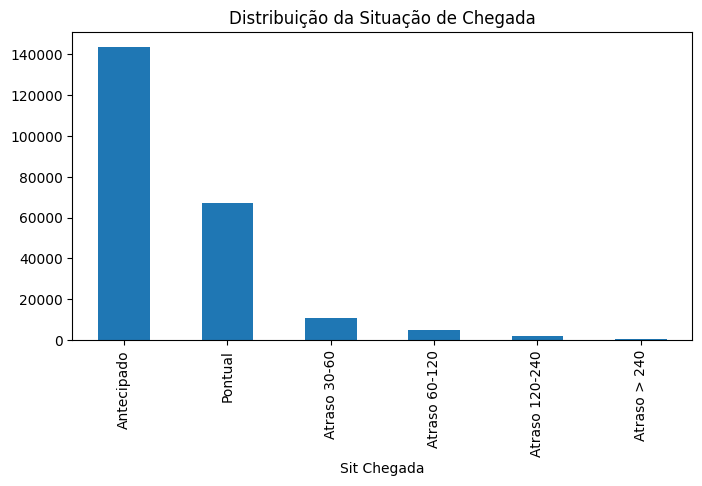

In [ ]:
import matplotlib.pyplot as plt

df['Sit Chegada'].value_counts().plot(
    kind='bar',
    figsize=(8,4)
)

plt.title('Distribuição da Situação de Chegada')
plt.show()

A maioria dos voos foi classificada como Antecipado ou Pontual.

As categorias de atraso representam uma parcela menor da base de dados, indicando um cenário naturalmente desbalanceado.

Essa característica deverá ser considerada durante a avaliação dos modelos, utilizando métricas além da acurácia.

### **4. Preparação dos dados**

#### 4.1 Remoção dos registros incompletos

In [ ]:
df = df.dropna()

print(df.shape)

(229779, 16)


Nesta etapa foram realizados os tratamentos necessários para adequar os dados ao processo de modelagem.

Inicialmente, foram removidos os registros que apresentavam valores ausentes nas variáveis Partida Prevista ou Situacao Chegada.

Como ambas as variáveis são fundamentais para o problema proposto, optou-se pela remoção desses registros.

In [ ]:
df.isnull().sum()

,0
Sigla Aerea,0
Tipo Voo,0
Modelo aeronave,0
Assentos,0
Origem,0
Destino,0
Partida Prevista,0
Sit Partida,0
Sit Chegada,0
atrasado,0


#### 4.2 Variável-alvo
Para transformar o problema em uma tarefa de classificação binária, foi criada a variável atrasado.

A variável recebeu valor:

- 0 para voos classificados como Pontual ou Antecipado;
- 1 para voos classificados em qualquer categoria de atraso.

Essa transformação simplifica a modelagem e permite avaliar a capacidade dos algoritmos em identificar voos com potencial de atraso.

In [ ]:
df['atrasado'] = df['Sit Chegada'].apply(
    lambda x: 1 if 'Atraso' in str(x) else 0
)

print(df['atrasado'].value_counts())

atrasado
0    211049
1     18730
Name: count, dtype: int64


#### 4.3 Engenharia de Atributos

A variável Partida Prevista foi convertida para o formato datetime.

A partir dela foram extraídos novos atributos temporais:

- hora_partida: hora prevista para a decolagem;
- minuto_partida: minuto previsto para a decolagem;
- dia_semana: dia da semana da operação, codificado de 0 (segunda-feira) a 6 (domingo);
- mes: mês da operação.
- periodo_dia: Vôos das 00:01 até 5:59 (madrugada), das 6:00 às 11:59 (manhã), das 12:00 às 17:59 (tarde) e vôos a partir das 18h (noite)

Além dos atributos temporais, foram realizados tratamentos em outras variáveis da base:

*   Tipo Voo: transformado em uma variável indicadora, diferenciando voos domésticos e internacionais;
*   Modelo Aeronave: mantido como atributo categórico para representar possíveis diferenças operacionais entre os diversos tipos de aeronaves.

A criação e seleção desses atributos teve como objetivo ampliar a capacidade dos modelos em identificar padrões associados à ocorrência de atrasos, incorporando não apenas informações temporais, mas também características operacionais do voo.

In [ ]:
df['Partida Prevista'] = pd.to_datetime(
    df['Partida Prevista'],
    format='%d/%m/%Y %H:%M',
    errors='coerce'
)
print(df['Partida Prevista'].dtype)
df['hora_partida'] = df['Partida Prevista'].dt.hour
df['minuto_partida'] = df['Partida Prevista'].dt.minute
df['dia_semana'] = df['Partida Prevista'].dt.dayofweek
df['mes'] = df['Partida Prevista'].dt.month
df['internacional'] = (
    df['Tipo Voo'] == 'I'
).astype(int)

# Período do dia
def periodo(hora):
    if hora < 6:
        return 'Madrugada'
    elif hora < 12:
        return 'Manha'
    elif hora < 18:
        return 'Tarde'
    else:
        return 'Noite'

df['periodo_dia'] = df['hora_partida'].apply(periodo)

datetime64[ns]


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 229779 entries, 0 to 240366
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Sigla Aerea       229779 non-null  object        
 1   Tipo Voo          229779 non-null  object        
 2   Modelo aeronave   229779 non-null  object        
 3   Assentos          229779 non-null  int64         
 4   Origem            229779 non-null  object        
 5   Destino           229779 non-null  object        
 6   Partida Prevista  229779 non-null  datetime64[ns]
 7   Sit Partida       229779 non-null  object        
 8   Sit Chegada       229779 non-null  object        
 9   atrasado          229779 non-null  int64         
 10  hora_partida      229779 non-null  int32         
 11  minuto_partida    229779 non-null  int32         
 12  dia_semana        229779 non-null  int32         
 13  mes               229779 non-null  int32         
 14  internaci

In [ ]:
df[['Partida Prevista',
    'hora_partida',
    'minuto_partida',
    'dia_semana',
    'mes',
    'internacional',
    'periodo_dia']].head()

,Partida Prevista,hora_partida,minuto_partida,dia_semana,mes,internacional,periodo_dia
0,2025-01-01 23:55:00,23,55,2,1,1,Noite
1,2025-01-01 01:10:00,1,10,2,1,1,Madrugada
2,2025-01-01 00:30:00,0,30,2,1,1,Madrugada
3,2025-01-01 23:50:00,23,50,2,1,1,Noite
4,2025-01-01 20:50:00,20,50,2,1,1,Noite


### **5. Análise dos Atributos**

Após a preparação dos dados, foi realizada uma nova análise exploratória das variáveis selecionadas para a modelagem.

O objetivo era verificar se houve alguma alteração no padrão após a remoção dos vôos de carga.

#### 5.1 Análise 1 — Companhias aéreas

In [ ]:
companhias = (
    df.groupby('Sigla Aerea')['atrasado']
      .mean()
      .sort_values(ascending=False)
)

companhias.head(15)

,atrasado
Sigla Aerea,
CKS,1.000000
HFY,0.800000
CJT,0.750000
GTI,0.750000
CLX,0.733333
GXA,0.714286
LYC,0.666667
NCR,0.628571
KAL,0.571429


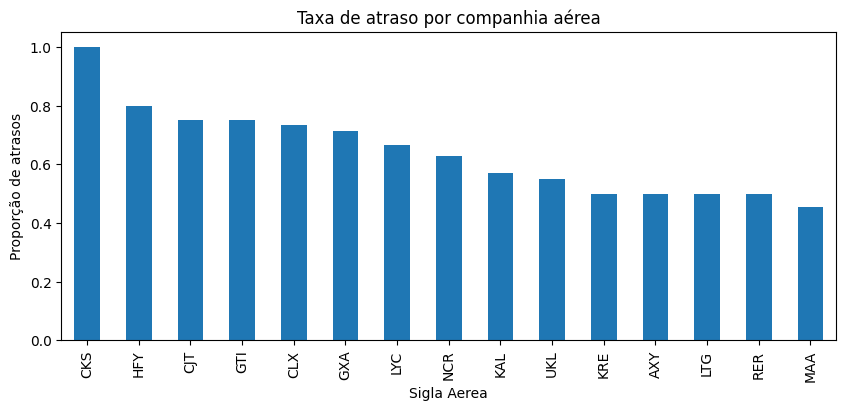

In [ ]:
import matplotlib.pyplot as plt

companhias.head(15).plot(
    kind='bar',
    figsize=(10,4)
)

plt.title('Taxa de atraso por companhia aérea')
plt.ylabel('Proporção de atrasos')
plt.show()

#### 5.2 Análise 2 — Hora da partida

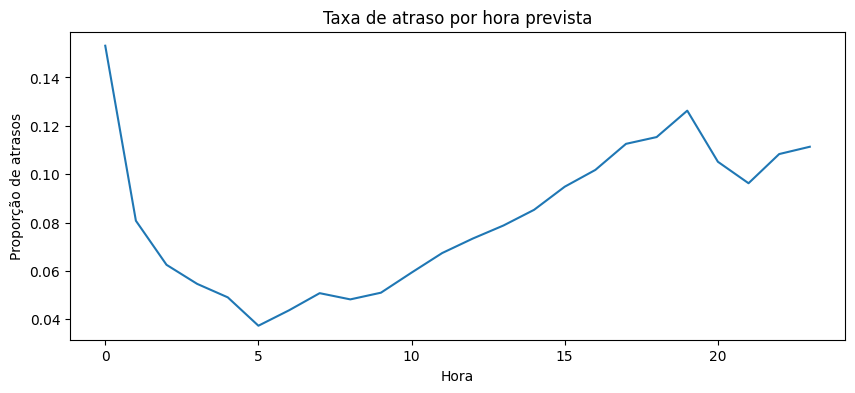

In [ ]:
hora = (
    df.groupby('hora_partida')['atrasado']
      .mean()
)

hora.plot(
    figsize=(10,4)
)

plt.title('Taxa de atraso por hora prevista')
plt.ylabel('Proporção de atrasos')
plt.xlabel('Hora')
plt.show()

#### 5.3 Análise 3 — Aeroportos de origem

In [ ]:
origem = (
    df.groupby('Origem')['atrasado']
      .mean()
      .sort_values(ascending=False)
)

origem.head(15)

,atrasado
Origem,
PANC,1.000000
KSEA,1.000000
SANT,1.000000
RKSI,1.000000
VTBS,1.000000
TJBQ,1.000000
TJSJ,1.000000
SYCJ,1.000000
TLPL,1.000000


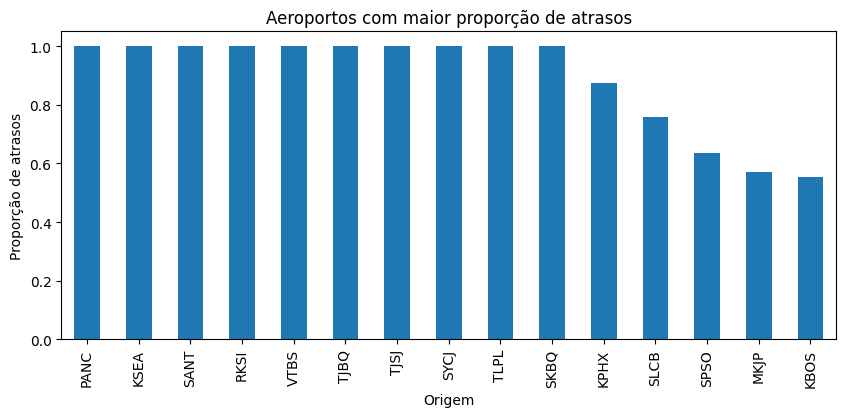

In [ ]:
origem.head(15).plot(
    kind='bar',
    figsize=(10,4)
)

plt.title('Aeroportos com maior proporção de atrasos')
plt.ylabel('Proporção de atrasos')
plt.show()

#### 5.4 Análise 4 — Aeroportos de destino

In [ ]:
destino = (
    df.groupby('Destino')['atrasado']
      .mean()
      .sort_values(ascending=False)
)

destino.head(15)

,atrasado
Destino,
MNMG,1.000000
PANC,1.000000
KSEA,1.000000
KTPA,1.000000
ZBTJ,1.000000
TJSJ,1.000000
SKPE,1.000000
ELLX,0.857143
MKJP,0.857143


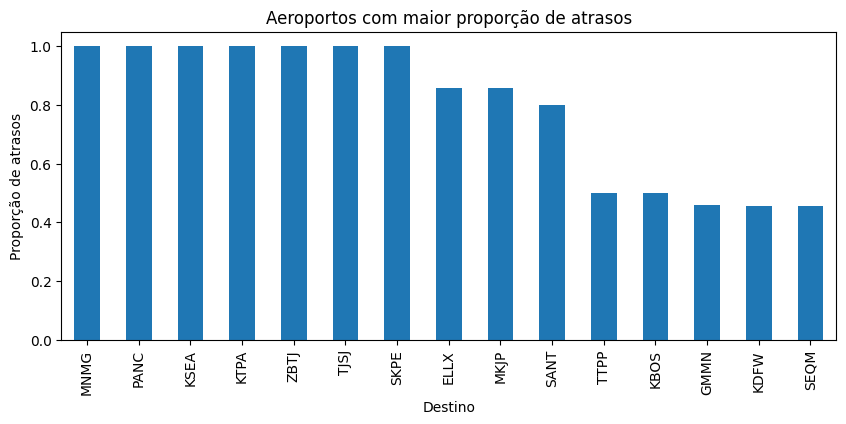

In [ ]:
destino.head(15).plot(
    kind='bar',
    figsize=(10,4)
)

plt.title('Aeroportos com maior proporção de atrasos')
plt.ylabel('Proporção de atrasos')
plt.show()

#### 5.5 Análise 5 - Tipo de vôo

In [ ]:
atraso_tipo = (
    df.groupby('internacional')['atrasado']
      .mean()
)

atraso_tipo

,atrasado
internacional,
0,0.073573
1,0.120106


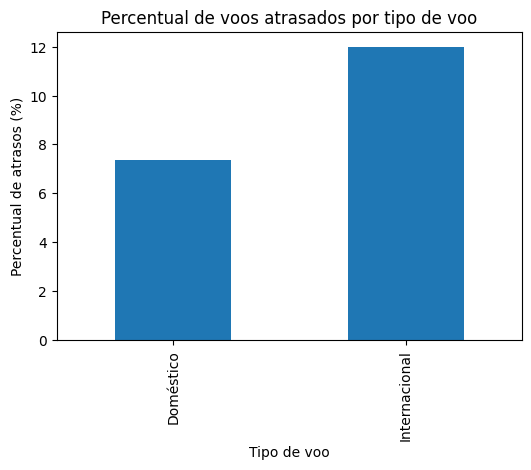

In [ ]:
import matplotlib.pyplot as plt

atraso_tipo.index = ['Doméstico', 'Internacional']

(atraso_tipo * 100).plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Percentual de voos atrasados por tipo de voo')
plt.ylabel('Percentual de atrasos (%)')
plt.xlabel('Tipo de voo')

plt.show()

#### 5.6 Análise 6 - Período do dia

In [ ]:
ordem = [
    'Madrugada',
    'Manha',
    'Tarde',
    'Noite'
]

atraso_periodo = (
    df.groupby('periodo_dia')['atrasado']
      .mean()
      .reindex(ordem)
)
atraso_periodo

,atrasado
periodo_dia,
Madrugada,0.062734
Manha,0.053445
Tarde,0.091826
Noite,0.110915


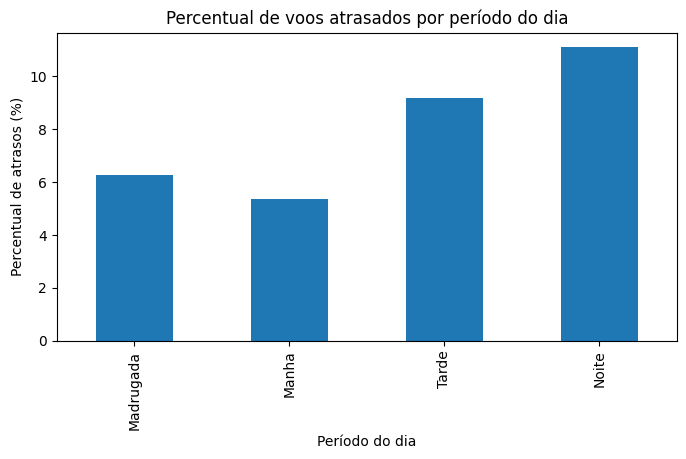

In [ ]:
import matplotlib.pyplot as plt

(atraso_periodo * 100).plot(
    kind='bar',
    figsize=(8,4)
)

plt.title('Percentual de voos atrasados por período do dia')
plt.ylabel('Percentual de atrasos (%)')
plt.xlabel('Período do dia')

plt.show()

#### 5.7 Análise 7 - Modelo da Aeronave

In [ ]:
modelo_atraso = (
    df.groupby('Modelo aeronave')['atrasado']
      .mean()
      .sort_values(ascending=False)
)

modelo_atraso.head(15)

,atrasado
Modelo aeronave,
B744,0.733333
B752,0.714286
C130,0.666667
B77F,0.571429
A343,0.571429
AN12,0.500000
B732,0.500000
E190,0.392857
B77L,0.333333


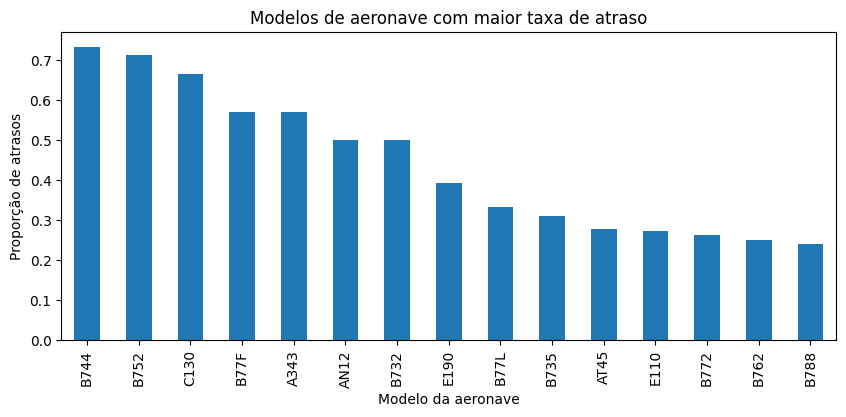

In [ ]:
import matplotlib.pyplot as plt

modelo_atraso.head(15).plot(
    kind='bar',
    figsize=(10,4)
)

plt.title('Modelos de aeronave com maior taxa de atraso')
plt.ylabel('Proporção de atrasos')
plt.xlabel('Modelo da aeronave')

plt.show()

#### 5.8 Refinamento da análise
A análise inicial identificou taxas extremamente elevadas de atraso para determinados valores de alguns atributos, chegando a 100% em alguns casos.

Entretanto, observou-se que parte desses resultados estava associada a grupos com quantidade muito reduzida de observações.

Nessas situações, uma única ocorrência de atraso pode produzir taxas artificialmente elevadas, comprometendo a interpretação dos resultados.

Por esse motivo, foi realizada uma análise complementar considerando também a quantidade de voos observados para cada um dos valores desses atributos.

In [ ]:
companhias_stats = (
    df.groupby('Sigla Aerea')
      .agg(
          taxa_atraso=('atrasado','mean'),
          qtd_voos=('atrasado','count')
      )
)

companhias_stats.sort_values(
    'taxa_atraso',
    ascending=False
).head(15)

,taxa_atraso,qtd_voos
Sigla Aerea,,
CKS,1.000000,2
HFY,0.800000,10
CJT,0.750000,8
GTI,0.750000,4
CLX,0.733333,30
GXA,0.714286,14
LYC,0.666667,3
NCR,0.628571,35
KAL,0.571429,7


In [ ]:
origem_stats = (
    df.groupby('Origem')
      .agg(
          taxa_atraso=('atrasado','mean'),
          qtd_voos=('atrasado','count')
      )
)

origem_stats.sort_values(
    'taxa_atraso',
    ascending=False
).head(15)

,taxa_atraso,qtd_voos
Origem,,
PANC,1.000000,1
KSEA,1.000000,1
SANT,1.000000,3
RKSI,1.000000,1
VTBS,1.000000,3
TJBQ,1.000000,1
TJSJ,1.000000,2
SYCJ,1.000000,1
TLPL,1.000000,1


In [ ]:
destino_stats = (
    df.groupby('Destino')
      .agg(
          taxa_atraso=('atrasado','mean'),
          qtd_voos=('atrasado','count')
      )
)

destino_stats.sort_values(
    'taxa_atraso',
    ascending=False
).head(15)

,taxa_atraso,qtd_voos
Destino,,
MNMG,1.000000,1
PANC,1.000000,1
KSEA,1.000000,1
KTPA,1.000000,1
ZBTJ,1.000000,1
TJSJ,1.000000,2
SKPE,1.000000,1
ELLX,0.857143,7
MKJP,0.857143,7


In [ ]:
tipo_stats = (
    df.groupby('Tipo Voo')
      .agg(
          taxa_atraso=('atrasado', 'mean'),
          qtd_voos=('atrasado', 'count')
      )
)

tipo_stats.sort_values(
    'taxa_atraso',
    ascending=False
)

,taxa_atraso,qtd_voos
Tipo Voo,,
I,0.120106,39207
N,0.073573,190572


In [ ]:
ordem = [
    'Madrugada',
    'Manha',
    'Tarde',
    'Noite'
]

periodo_stats = (
    df.groupby('periodo_dia')
      .agg(
          taxa_atraso=('atrasado', 'mean'),
          qtd_voos=('atrasado', 'count')
      )
      .reindex(ordem)
)

periodo_stats

,taxa_atraso,qtd_voos
periodo_dia,,
Madrugada,0.062734,25935
Manha,0.053445,71382
Tarde,0.091826,73552
Noite,0.110915,58910


In [ ]:
modelo_stats = (
    df.groupby('Modelo aeronave')
      .agg(
          taxa_atraso=('atrasado', 'mean'),
          qtd_voos=('atrasado', 'count')
      )
)

modelo_stats.sort_values(
    'taxa_atraso',
    ascending=False
).head(15)

,taxa_atraso,qtd_voos
Modelo aeronave,,
B744,0.733333,60
B752,0.714286,7
C130,0.666667,3
B77F,0.571429,7
A343,0.571429,7
AN12,0.500000,34
B732,0.500000,2
E190,0.392857,28
B77L,0.333333,3


#### 5.9 Análise com Controle de Frequência

A análise complementar confirmou que parte dos resultados observados inicialmente estava associada a grupos com número reduzido de observações.

Valores de atributos que apresentavam taxas de atraso extremamente elevadas frequentemente possuíam apenas alguns poucos voos registrados na base de dados.

Para reduzir o impacto de flutuações ocasionais e aumentar a confiabilidade das interpretações, foi aplicado um critério mínimo de frequência, considerando apenas grupos com pelo menos 100 voos registrados.

Essa abordagem permitiu identificar padrões mais consistentes e representativos do comportamento operacional observado no período analisado.

In [ ]:
companhias_filtradas = companhias_stats[
    companhias_stats['qtd_voos'] >= 100
]

companhias_filtradas.head(15)

,taxa_atraso,qtd_voos
Sigla Aerea,,
AAL,0.268344,1431
ABJ,0.017493,343
ACA,0.222868,516
ACN,0.145092,3708
AEA,0.144531,256
AFR,0.177070,785
AMX,0.088889,180
ARE,0.071823,181
ARG,0.093501,2631


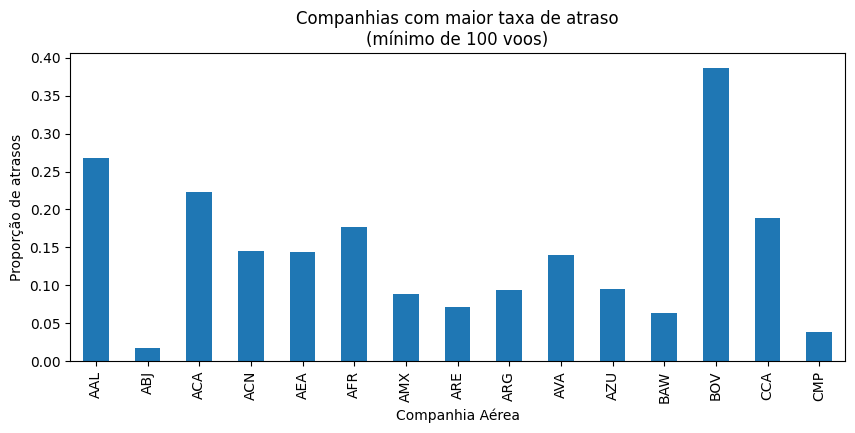

In [ ]:
companhias_filtradas.head(15)['taxa_atraso'].plot(
    kind='bar',
    figsize=(10,4)
)

plt.title(
    'Companhias com maior taxa de atraso\n(mínimo de 100 voos)'
)

plt.ylabel('Proporção de atrasos')
plt.xlabel('Companhia Aérea')
plt.show()

In [ ]:
origem_filtrada = origem_stats[
    origem_stats['qtd_voos'] >= 100
]

origem_filtrada.head(15)

,taxa_atraso,qtd_voos
Origem,,
EDDF,0.042194,237
EGLL,0.062500,304
EHAM,0.084270,178
KATL,0.163569,269
KDFW,0.269737,152
KFLL,0.135231,281
KIAH,0.220994,181
KJFK,0.150000,440
KMCO,0.083512,467


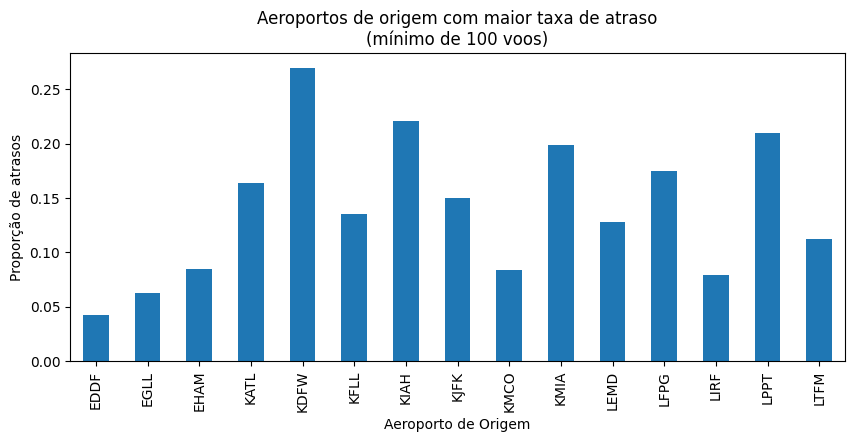

In [ ]:
origem_filtrada.head(15)['taxa_atraso'].plot(
    kind='bar',
    figsize=(10,4)
)

plt.title(
    'Aeroportos de origem com maior taxa de atraso\n(mínimo de 100 voos)'
)

plt.ylabel('Proporção de atrasos')
plt.xlabel('Aeroporto de Origem')
plt.show()

In [ ]:
destino_filtrado = destino_stats[
    destino_stats['qtd_voos'] >= 100
]

destino_filtrado.head(15)

,taxa_atraso,qtd_voos
Destino,,
EDDF,0.209205,239
EGLL,0.135849,265
EHAM,0.079096,177
KATL,0.252830,265
KDFW,0.456954,151
KFLL,0.147887,284
KIAH,0.144444,180
KJFK,0.188940,434
KMCO,0.047228,487


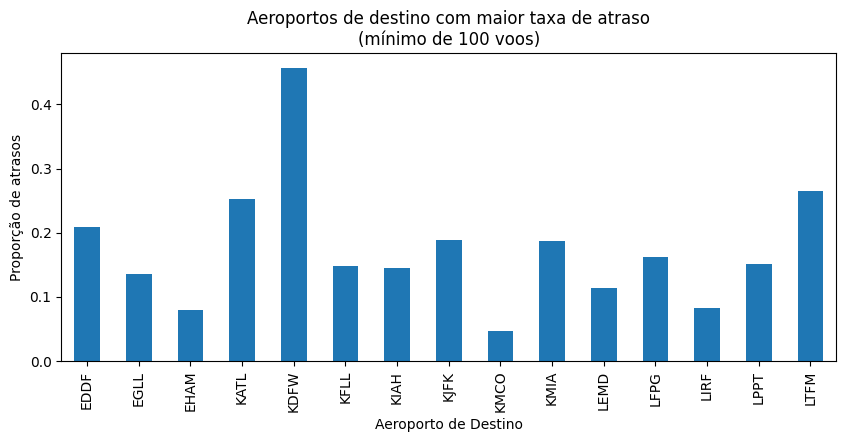

In [ ]:
destino_filtrado.head(15)['taxa_atraso'].plot(
    kind='bar',
    figsize=(10,4)
)

plt.title(
    'Aeroportos de destino com maior taxa de atraso\n(mínimo de 100 voos)'
)

plt.ylabel('Proporção de atrasos')
plt.xlabel('Aeroporto de Destino')
plt.show()

In [ ]:
modelo_filtrado = modelo_stats[
    modelo_stats['qtd_voos'] >= 100
]

modelo_filtrado.head(15)

,taxa_atraso,qtd_voos
Modelo aeronave,,
A20N,0.102892,23860
A21N,0.095039,3104
A319,0.045840,10733
A320,0.063433,40326
A321,0.080782,19633
A330,0.054422,588
A332,0.163121,1128
A333,0.230624,529
A339,0.134185,2191


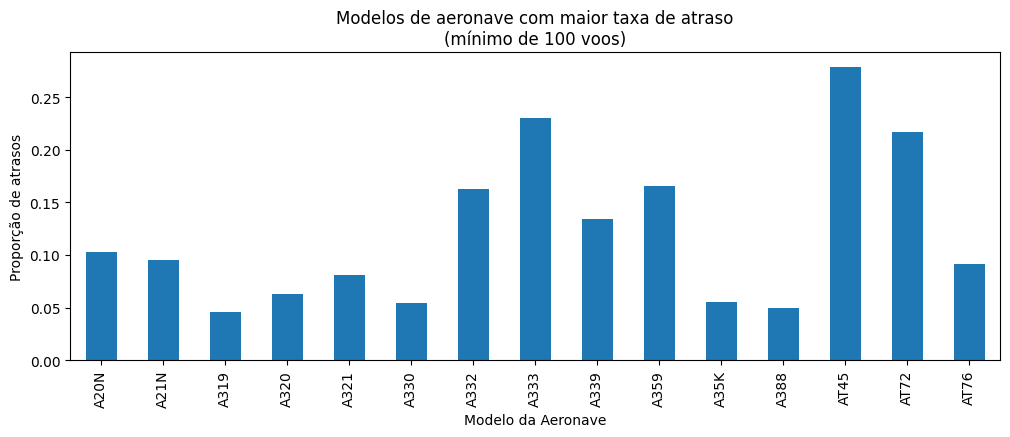

In [ ]:
modelo_filtrado.head(15)['taxa_atraso'].plot(
    kind='bar',
    figsize=(12,4)
)

plt.title(
    'Modelos de aeronave com maior taxa de atraso\n(mínimo de 100 voos)'
)

plt.ylabel('Proporção de atrasos')
plt.xlabel('Modelo da Aeronave')
plt.show()

### **6. Preparação para Modelagem**

Após a etapa de análise exploratória e engenharia de atributos, os dados foram preparados para utilização nos algoritmos de Machine Learning.

A variável-alvo utilizada foi `atrasado`, criada durante a etapa de preparação dos dados.

As variáveis categóricas foram transformadas para formato numérico por meio de codificação apropriada, permitindo sua utilização pelos algoritmos de classificação.

Por fim, os dados foram divididos em conjuntos de treinamento e teste para avaliação do desempenho dos modelos.

#### 6.1 Definição de x e y
Como variáveis preditoras foram selecionadas informações operacionais disponíveis antes da realização do voo, incluindo companhia aérea, modelo da aeronave, capacidade de assentos, aeroportos de origem e destino, horário previsto de partida, dia da semana, mês da operação, tipo de voo (doméstico ou internacional) e período do dia.

A inclusão dos novos atributos teve como objetivo ampliar a capacidade dos modelos em identificar padrões associados à ocorrência de atrasos, incorporando características operacionais e temporais potencialmente relevantes para o problema.

In [ ]:
X = df[
    [
        'Sigla Aerea',
        'Modelo aeronave',
        'Assentos',
        'Origem',
        'Destino',
        'hora_partida',
        'minuto_partida',
        'dia_semana',
        'mes',
        'internacional',
        'periodo_dia'
    ]
]

y = df['atrasado']

print(X.shape)
print(y.shape)

(229779, 11)
(229779,)


#### 6.2 One Hot encoding
As variáveis Sigla Aerea, Modelo aeronave, Origem, Destino e periodo_dia possuem natureza categórica e não podem ser utilizadas diretamente por alguns algoritmos de Machine Learning.

Para resolver esse problema foi utilizada a técnica One-Hot Encoding, que transforma cada categoria em uma variável binária.

Essa abordagem permite representar informações categóricas de forma adequada sem introduzir relações artificiais entre categorias.

A variável internacional já se encontra em formato numérico binário (0 para voos domésticos e 1 para voos internacionais), não sendo necessária nenhuma transformação adicional.

In [ ]:
X = pd.get_dummies(
    X,
    columns=[
        'Sigla Aerea',
        'Modelo aeronave',
        'Origem',
        'Destino',
        'periodo_dia'
    ],
    drop_first=True
)

print(X.shape)

(229779, 614)


#### 6.3 Divisão de dados
Os dados foram divididos em conjuntos de treinamento e teste.

O conjunto de treinamento foi utilizado para o ajuste dos modelos, enquanto o conjunto de teste foi reservado para avaliação final do desempenho.

Foi adotada uma divisão de 80% para treinamento e 20% para teste.

Além disso, utilizou-se a estratégia de estratificação da variável-alvo, preservando a proporção entre voos atrasados e não atrasados em ambos os conjuntos.

A estratificação é particularmente importante neste trabalho devido ao desbalanceamento identificado entre as classes, reduzindo o risco de avaliações enviesadas dos modelos.

Foi utilizado random_state=42 para garantir a reprodutibilidade dos experimentos.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(183823, 614)
(45956, 614)
(183823,)
(45956,)


### **7. Modelo baseline**
Antes do treinamento dos modelos de Machine Learning foi definido um modelo baseline para servir como referência de comparação.

O baseline adotado consiste em prever que todos os voos serão classificados como não atrasados.

Essa abordagem representa uma estratégia extremamente simples, mas adequada para avaliar se os modelos treinados conseguem capturar padrões relevantes nos dados e superar uma solução ingênua.

Como a base apresenta predominância de voos não atrasados, espera-se que o baseline apresente elevada acurácia, porém baixo desempenho na identificação dos casos de atraso.

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

baseline = DummyClassifier(
    strategy='most_frequent'
)

baseline.fit(X_train, y_train)

y_pred_baseline = baseline.predict(X_test)

In [ ]:
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_baseline)
)

Accuracy: 0.9184872486726434


In [ ]:
confusion_matrix(
    y_test,
    y_pred_baseline
)

array([[42210,     0],
       [ 3746,     0]])

A análise das métricas revelou que o modelo baseline não realizou nenhuma previsão da classe correspondente aos voos atrasados.

Como consequência, as métricas Precision, Recall e F1-Score para essa classe foram iguais a zero.

Esse resultado reforça a limitação de modelos que consideram apenas a classe majoritária em bases desbalanceadas.

In [ ]:
print(
    classification_report(
        y_test,
        y_pred_baseline
    )
)

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     42210
           1       0.00      0.00      0.00      3746

    accuracy                           0.92     45956
   macro avg       0.46      0.50      0.48     45956
weighted avg       0.84      0.92      0.88     45956



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### **8. Logistic Regression**

Novamente, de forma análoga à parte 1, foi utilizado o algoritmo Logistic Regression primeiramente.

Como o algoritmo é sensível à escala das variáveis numéricas, foi aplicada uma etapa de padronização utilizando o StandardScaler antes do treinamento.

In [ ]:
X_train_lr = X_train.copy()
X_test_lr = X_test.copy()

In [ ]:
colunas_numericas = [
    'Assentos',
    'hora_partida',
    'minuto_partida',
    'dia_semana',
    'mes'
]

colunas_numericas

['Assentos', 'hora_partida', 'minuto_partida', 'dia_semana', 'mes']

#### 8.1 Padronização das Variáveis

As variáveis numéricas foram padronizadas utilizando o StandardScaler.

O ajuste do escalonador foi realizado exclusivamente sobre o conjunto de treinamento, sendo posteriormente aplicado ao conjunto de teste.

Essa abordagem evita vazamento de informação entre os conjuntos e garante uma avaliação mais realista do modelo.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_lr[colunas_numericas] = scaler.fit_transform(
    X_train_lr[colunas_numericas]
)

X_test_lr[colunas_numericas] = scaler.transform(
    X_test_lr[colunas_numericas]
)

In [ ]:
X_train_lr[colunas_numericas].describe()

,Assentos,hora_partida,minuto_partida,dia_semana,mes
count,1.838230e+05,1.838230e+05,1.838230e+05,1.838230e+05,1.838230e+05
mean,-2.563509e-16,-1.204061e-16,7.661151e-17,8.171379e-17,-1.729750e-17
std,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00,1.000003e+00
min,-2.916698e+00,-2.186847e+00,-1.502908e+00,-1.500047e+00,-1.175486e+00
25%,-5.732568e-01,-8.288405e-01,-9.357459e-01,-9.966430e-01,-1.175486e+00
50%,1.399646e-01,1.991321e-02,-8.500316e-02,1.016541e-02,3.067517e-02
75%,2.418534e-01,8.686669e-01,7.657396e-01,1.016974e+00,1.236836e+00
max,5.828754e+00,1.717421e+00,1.843347e+00,1.520378e+00,2.442997e+00


#### 8.2 Treinamento do modelo

In [ ]:
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

modelo_lr.fit(
    X_train_lr,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

#### 8.3 Teste do modelo

In [ ]:
y_pred_lr = modelo_lr.predict(
    X_test_lr
)

#### 8.4 Acurácia

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(
    y_test,
    y_pred_lr
)

0.6427234746279049

#### 8.5 Matriz de confusão

In [ ]:
confusion_matrix(y_test, y_pred_lr)

array([[27211, 14999],
       [ 1420,  2326]])

In [ ]:
print(classification_report(
    y_test,
    y_pred_lr)
)

              precision    recall  f1-score   support

           0       0.95      0.64      0.77     42210
           1       0.13      0.62      0.22      3746

    accuracy                           0.64     45956
   macro avg       0.54      0.63      0.49     45956
weighted avg       0.88      0.64      0.72     45956



### **9. Random Forest**

#### 9.1 Treinamento do modelo

In [ ]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

modelo_rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)